# Learning Representations by Back-Propagating Errors
**Authors:** David E. Rumelhart, Geoffrey E. Hinton, Ronald J. Williams (Nature, Vol. 323, 9 October 1986)

# https://www.iro.umontreal.ca/~vincentp/ift3395/lectures/backprop_old.pdf

## Abstract
The paper introduces the back-propagation algorithm, a general-purpose procedure for training layered networks of neuron-like units. The method adjusts connection weights by propagating the derivative of an output error measure backward through the network, enabling hidden units—those with no direct input or output role—to develop internal representations that capture task-relevant regularities. The authors demonstrate that this simple, gradient-based procedure is sufficiently powerful to construct useful internal representations for several benchmark problems, distinguishing back-propagation from earlier, more limited approaches such as the perceptron-convergence procedure.

## Problems
- Existing self-organizing neural network rules lacked a general and powerful method for adjusting weights in networks with **hidden units**, whose desired states are not directly specified by the task.
- In perceptrons, "feature analysers" between input and output are not true hidden units because their input connections are fixed by hand; their states are fully determined by the input vector, so they do not learn representations.
- Learning becomes substantially harder once internal (hidden) layers are introduced, since the network itself must decide what these units should represent.
- Some tasks (e.g., detecting symmetry) cannot be solved by directly connecting inputs to outputs, requiring an intermediate layer that back-propagation must learn to configure appropriately.

## Proposed Solutions
- **Back-propagation algorithm**: a two-pass procedure (forward pass, then backward pass) that computes the partial derivative of the total error with respect to each weight and adjusts weights via gradient descent.
- Units use a linear combination of inputs followed by a smooth nonlinearity, enabling differentiable computation of error gradients throughout the network.
- The backward pass propagates $$\partial E / \partial y$$ from the output layer back to earlier layers using the chain rule, allowing derivatives to be computed for arbitrarily many layers.
- An **acceleration method** using a momentum term is proposed to speed convergence without sacrificing simplicity or locality of computation.
- A **weight-decay** technique is introduced to aid interpretability of learned weights by shrinking each weight proportionally after every update.

## Purpose
To provide a general, biologically-inspired (though not claimed as biologically plausible) learning procedure capable of automatically discovering internal representations in multi-layer neural networks, overcoming the representational limitations of single-layer perceptron-style learning rules.

## Methodology
**Network Architecture**
- Layered, feed-forward networks with an input layer, one or more intermediate (hidden) layers, and an output layer.
- Connections within a layer or from higher to lower layers are forbidden; connections may skip intermediate layers.

**Unit Computation**
- Total input to unit $j$:
$$x_j = \sum_i y_i w_{ji} \quad (1)$$
- Output via logistic (sigmoid) nonlinearity:
$$y_j = \frac{1}{1 + e^{-x_j}} \quad (2)$$

**Error Function**
- Total error summed over cases $c$ and output units $j$:
$$E = \frac{1}{2} \sum_c \sum_j (y_{j,c} - d_{j,c})^2 \quad (3)$$

**Backward Pass Derivations**
$$\partial E / \partial y_j = y_j - d_j \quad (4)$$
$$\partial E / \partial x_j = \partial E / \partial y_j \cdot y_j (1 - y_j) \quad (5)$$
$$\partial E / \partial w_{ji} = \partial E / \partial x_j \cdot y_i \quad (6)$$
$$\partial E / \partial y_i = \sum_j \partial E / \partial x_j \cdot w_{ji} \quad (7)$$

**Weight Update Rules**
- Basic gradient descent:
$$\Delta w = -\varepsilon \, \partial E / \partial w \quad (8)$$
- Accelerated version with momentum:
$$\Delta w(t) = -\varepsilon \, \partial E / \partial w(t) + \alpha \, \Delta w(t-1) \quad (9)$$

**Experimental Tasks**
1. **Mirror symmetry detection**: a one-dimensional binary input array; network trained to detect symmetry about the centre point using two hidden units (1,425 sweeps through 64 possible input vectors; $\varepsilon = 0.1$, $\alpha = 0.9$).
2. **Family-tree relational learning**: two isomorphic 12-person family trees encoded as triples (person1, relationship, person2); a five-layer network with 24 input units for person1, 12 for relationship, and a distributed encoding architecture trained on 100 of 104 possible triples over 1,500 sweeps (varying $\varepsilon$ and $\alpha$ across training phases), tested for generalization on the 4 held-out triples.
3. **Iterative/recurrent net equivalence**: demonstration that a synchronous iterative (recurrent) network run for multiple time-steps is mathematically equivalent to a layered feed-forward net, with corresponding weights constrained to be equal (via gradient averaging across corresponding weight sets).

## Results
- The symmetry-detection network discovered an elegant two-hidden-unit solution exploiting weight symmetry (equal magnitude, opposite sign) about the input midpoint, correctly generalizing to all symmetric and non-symmetric patterns.
- In the family-tree task, hidden units at the second layer learned distributed representations encoding meaningful features such as nationality (English vs. Italian), generation, and branch of the family, despite these features not being explicit in the input/output encoding.
- The network exploited structural isomorphism between the two family trees to generalize correctly to the four held-out triples not seen during training.
- The learning procedure was empirically found to rarely become trapped in poor local minima, even though gradient descent offers no such guarantee; networks with minimal connectivity for the task were more prone to this issue, while additional connections (extra weight-space dimensions) provided escape paths around barriers.
- The equivalence between layered and iterative (recurrent) networks was formally established, extending the applicability of back-propagation to networks that perform iterative search or learn sequential structures.

## Conclusions
- Back-propagation constitutes a general-purpose, computationally simple, and locally implementable procedure capable of enabling networks to autonomously construct internal representations suited to a task's structure and regularities.
- The procedure is not proposed as a biologically plausible model of learning in the brain in its current form; however, its success in constructing useful internal representations motivates further investigation into more biologically plausible mechanisms for performing gradient descent in neural networks.
- The work distinguishes itself from earlier learning rules (e.g., perceptron-convergence) precisely through its capacity to create novel, task-appropriate hidden-unit features rather than relying on fixed, hand-designed feature detectors.

# Mathematical and Statistical Content Summary
**Paper:** Learning Representations by Back-Propagating Errors (Rumelhart, Hinton & Williams, 1986)

## 1. Unit Input Function (Linear Combination)
$$x_j = \sum_i y_i w_{ji} \quad (1)$$

**Explanation:** Each unit $j$ computes a weighted sum of the outputs $y_i$ of all units connected to it, using connection weights $w_{ji}$. This is simple linear aggregation — the same idea as a weighted average — and forms the raw "signal" a unit receives before any nonlinearity is applied. Biases are handled by treating them as an extra input that is always 1, with its own weight acting as a threshold.

## 2. Logistic (Sigmoid) Activation Function
$$y_j = \frac{1}{1 + e^{-x_j}} \quad (2)$$

**Explanation:** This function squashes the unit's total input $x_j$ into an output between 0 and 1. It is a smooth, continuously differentiable "S-shaped" curve, which is essential because the learning procedure requires computing derivatives. The authors note any bounded, differentiable function would work, but the logistic function's smoothness simplifies the calculus.

## 3. Total Error Function (Sum of Squared Errors)
$$E = \frac{1}{2} \sum_c \sum_j (y_{j,c} - d_{j,c})^2 \quad (3)$$

**Explanation:** This is a standard **sum-of-squared-errors** loss, a common statistical measure of fit. It sums, over every training case $c$ and every output unit $j$, the squared difference between the actual output $y_{j,c}$ and the desired (target) output $d_{j,c}$. The factor $\frac{1}{2}$ is a convenience that cancels out when differentiating. Minimizing $E$ is the entire learning objective — smaller $E$ means the network's outputs match the desired outputs more closely.

## 4. Gradient Descent (Optimization Method)
**Explanation:** Gradient descent is the general statistical/optimization technique used to minimize $E$. The idea: compute how much a small change in each weight would change the total error, then move each weight slightly in the direction that reduces error. This requires computing partial derivatives $\partial E/\partial w$ for every weight — this is what the "backward pass" (below) accomplishes efficiently using the chain rule.

## 5. Backward Pass: Chain Rule Derivations
These four equations apply the **chain rule of calculus** repeatedly to propagate error derivatives from the output layer back through the network.

**(a) Error derivative with respect to output:**
$$\partial E / \partial y_j = y_j - d_j \quad (4)$$
Simple derivative of the squared-error term: the error signal at an output unit is just the difference between actual and desired output.

**(b) Error derivative with respect to total input (using the sigmoid's derivative):**
$$\partial E / \partial x_j = \partial E / \partial y_j \cdot y_j (1 - y_j) \quad (5)$$
The term $y_j(1-y_j)$ is the derivative of the logistic function — a well-known convenient property (the sigmoid's derivative can be written in terms of its own output). This converts the "output-space" error signal into an "input-space" error signal.

**(c) Error derivative with respect to a weight:**
$$\partial E / \partial w_{ji} = \partial E / \partial x_j \cdot y_i \quad (6)$$
Tells how much changing a specific weight $w_{ji}$ affects total error: it is the product of the unit's input-error signal and the activity of the sending unit $y_i$. This is the quantity gradient descent actually uses to update each weight.

**(d) Error derivative propagated to a lower layer:**
$$\partial E / \partial y_i = \sum_j \partial E / \partial x_j \cdot w_{ji} \quad (7)$$
This is the key recursive step: it lets the error signal be pushed backward one layer at a time, from the layer above ($j$) to the layer below ($i$), by summing contributions weighted by connection strengths. Repeating this equation layer by layer is what makes back-propagation efficient for networks of arbitrary depth.

## 6. Weight Update Rule (Basic Gradient Descent Step)
$$\Delta w = -\varepsilon \, \partial E / \partial w \quad (8)$$

**Explanation:** Each weight is changed by a small amount proportional to the negative of its error gradient (moving "downhill" on the error surface). $\varepsilon$ is the **learning rate**, a hyperparameter controlling step size. Two variants are discussed: updating after every single training case (online), or accumulating the gradient over all cases before updating (batch).

## 7. Momentum-Accelerated Update Rule
$$\Delta w(t) = -\varepsilon \, \partial E / \partial w(t) + \alpha \, \Delta w(t-1) \quad (9)$$

**Explanation:** This modifies the basic update by adding a fraction $\alpha$ (between 0 and 1) of the previous weight change. This is a **momentum term** — it treats optimization like a ball rolling downhill, where the current gradient acts as an acceleration rather than the sole determinant of velocity. It smooths out oscillations and speeds convergence without requiring costly second-derivative computations, while remaining simple and local (each weight only needs its own history).

## 8. Weight-Decay Regularization
**Explanation:** Described qualitatively rather than by a labeled equation: each weight is decremented by 0.2% after every update. This is a simple form of **regularization**, shrinking unused or unimportant weights toward zero so that only weights actually useful for reducing error remain large. This aids interpretability of the learned solution (e.g., in Fig. 4's receptive fields).

## 9. Symmetry Argument in the Mirror-Symmetry Task (Structural/Combinatorial Reasoning)
**Explanation:** Not a formal statistical method, but a mathematical argument: the network's solution exploits weights that are symmetric in magnitude but opposite in sign about the input midpoint. This guarantees the net input to hidden units is exactly balanced (zero) for symmetric patterns and imbalanced otherwise. It is essentially an algebraic proof, embedded in the learned weights, that the ratio of weights (1:2:4 in the example) uniquely separates symmetric from non-symmetric input patterns.

## 10. Equivalence of Iterative and Layered Networks (Averaging Constraint)
**Explanation:** For a recurrent (iterative) network run over several time steps to be trained using back-propagation, corresponding weights across "unrolled" layers must remain equal. This is enforced statistically by **averaging** the gradient $\partial E/\partial w$ across all corresponding weight copies, then applying that single averaged gradient to every copy equally. This is a constrained optimization technique ensuring weight-sharing is respected during learning — a precursor to the modern concept used in recurrent neural networks.

## Summary Table

| Concept | Equation # | Role in Paper |
|---|---|---|
| Weighted input sum | (1) | Aggregates incoming signals to a unit |
| Logistic activation | (2) | Introduces differentiable nonlinearity |
| Sum-of-squares error | (3) | Defines the objective to minimize |
| Output error derivative | (4) | Starting point of backward pass |
| Input error derivative | (5) | Applies sigmoid derivative via chain rule |
| Weight gradient | (6) | Computes each weight's contribution to error |
| Backward error propagation | (7) | Recursively pushes error signal to earlier layers |
| Basic weight update | (8) | Gradient descent step |
| Momentum update | (9) | Accelerates and stabilizes convergence |
| Weight decay | (unlabeled) | Regularizes weights for interpretability |

# Problem–Limitation–Solution Analysis
**Paper:** Learning Representations by Back-Propagating Errors (Rumelhart, Hinton & Williams, 1986)

| # | Key Problem / Research Gap | Limitation in Prior Work | Proposed Solution in This Paper |
|---|---|---|---|
| 1 | Absence of a general learning rule for networks containing **hidden units** whose desired states are not specified by the task | Earlier self-organizing rules could adjust weights only when input units connect directly to output units; learning becomes difficult once internal units must be configured without explicit targets | Introduces **back-propagation**: a two-pass procedure that computes $$\partial E / \partial w$$ for every weight, including those feeding hidden units, via the chain rule, allowing hidden units to learn appropriate internal representations |
| 2 | Perceptron-style "feature analysers" do not constitute true hidden units | In perceptrons, input connections to intermediate feature detectors are fixed by hand, so their states are fully determined by the input vector; the network cannot learn what these units should represent | Back-propagation allows the network to autonomously decide, through gradient descent, when hidden units should be active, so representations are learned rather than hand-designed |
| 3 | Some tasks cannot be solved by connecting inputs directly to outputs (e.g., detecting symmetry in an input array) | Without an intermediate layer, no learning rule can capture whole-vector properties like symmetry, since individual input units provide no evidence about the input pattern as a whole | Demonstrates that back-propagation, applied to a network with an intermediate layer, discovers an elegant weight-symmetric solution using only two hidden units |
| 4 | Efficient computation of error derivatives across many-layered networks | Prior local learning rules lacked an efficient way to compute how earlier-layer weights affect final output error, making deep or multi-layer learning impractical | Formulates a recursive backward pass (Eqs. 4–7) that propagates $$\partial E/\partial y$$ layer by layer from output to input, enabling efficient, local computation of all weight gradients |
| 5 | Basic gradient descent converges slowly and can oscillate | Standard weight-update rules using only the current gradient are simple but converge less rapidly than methods using second derivatives, which are computationally expensive | Proposes a **momentum-based acceleration method** (Eq. 9) that incorporates a fraction of the previous weight change, improving convergence speed while preserving simplicity and local computability |
| 6 | Learned weights are difficult to interpret after training | Standard gradient descent may leave many weights nonzero even when they contribute little to reducing error, obscuring which weights are functionally important | Introduces **weight-decay**, decrementing each weight by a small fixed proportion after every update, so that the final magnitude of each weight better reflects its actual usefulness |
| 7 | Gradient descent offers no guarantee against becoming trapped in poor local minima | This is a known theoretical weakness of gradient-based learning, raising doubt about its practical reliability | Provides empirical evidence across multiple tasks that the procedure rarely becomes trapped in significantly poor local minima, and shows that adding extra connections (more weight-space dimensions) creates paths around such minima |
| 8 | No established equivalence between recurrent (iterative) networks and layered feed-forward networks for learning purposes | Without such an equivalence, back-propagation could not be directly applied to networks that must perform iterative computation or process sequential structure | Proves that a synchronous iterative network run for a fixed number of steps is equivalent to a layered network with shared (corresponding) weights, and shows how to average gradients across corresponding weight sets to preserve this equivalence during learning |
| 9 | Uncertainty over whether internal representations can capture abstract structure not explicit in the input/output encoding (e.g., relational or hierarchical knowledge) | Earlier approaches lacked a demonstrated mechanism for extracting abstract features (e.g., generation, nationality) from symbolic, non-explicit encodings such as family-tree relationships | Trains a network on the family-tree relational task and shows hidden units spontaneously encode meaningful abstract features (nationality, generation, family branch), and that these representations generalize correctly to unseen relational triples |

In [1]:
# ============================================================
# Educational Replication of Back-Propagation (Rumelhart, Hinton & Williams, 1986)
# Applied to CIFAR-10 Image Classification
#
# This notebook manually implements the paper's forward pass, error
# signals, weight gradients, and momentum update rule using explicit
# PyTorch tensor operations (no autograd, no optimizers).
# ============================================================

# !pip -q install datasets scikit-learn

import random
import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms
from datasets import load_dataset
from PIL import Image

import matplotlib
import matplotlib.pyplot as plt
from matplotlib import gridspec
from sklearn.decomposition import PCA

from io import BytesIO
from IPython.display import display, Image as IPImage

In [2]:
# ------------------------------------------------------------
# 0. GLOBAL WHITE VISUAL THEME
# ------------------------------------------------------------
# The paper predates modern plotting conventions; we simply enforce
# a clean, readable, publication-style white theme throughout.
matplotlib.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "black",
    "axes.labelcolor": "black",
    "axes.titlecolor": "black",
    "text.color": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "grid.color": "0.85",
    "legend.facecolor": "white",
    "legend.edgecolor": "black",
    "legend.labelcolor": "black",
    "font.size": 10,
})

In [3]:
# ------------------------------------------------------------
# 1. REPRODUCIBILITY AND DEVICE
# ------------------------------------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [4]:
# ------------------------------------------------------------
# 2. CLASS NAMES (CIFAR-10, labels 0-9)
# ------------------------------------------------------------
class_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

In [ ]:
# ------------------------------------------------------------
# 3. DATASET — HUGGINGFACE CIFAR-10 ONLY
# ------------------------------------------------------------
ds = load_dataset("uoft-cs/cifar10")

train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225]),
])

test_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225]),
])


class HFCifar10Dataset(Dataset):
    """Wraps a HuggingFace CIFAR-10 split into a standard PyTorch Dataset."""

    def __init__(self, hf_split, transform):
        self.hf_split = hf_split
        self.transform = transform

    def __len__(self):
        return len(self.hf_split)

    def __getitem__(self, idx):
        record = self.hf_split[idx]
        img = record["img"]
        if not isinstance(img, Image.Image):
            img = Image.fromarray(np.array(img))
        if img.mode != "RGB":
            img = img.convert("RGB")
        img_tensor = self.transform(img)
        label = int(record["label"])
        return img_tensor, label


full_train_dataset = HFCifar10Dataset(ds["train"], train_transform)
full_test_dataset = HFCifar10Dataset(ds["test"], test_transform)

In [6]:
# ------------------------------------------------------------
# 4. SUBSETS AND DATALOADERS
# ------------------------------------------------------------
train_dataset = Subset(full_train_dataset, list(range(2000)))
test_dataset = Subset(full_test_dataset, list(range(400)))

pin_mem = torch.cuda.is_available()

train_loader = DataLoader(
    train_dataset, batch_size=64, shuffle=True,
    num_workers=2, pin_memory=pin_mem
)
eval_loader = DataLoader(
    test_dataset, batch_size=64, shuffle=False,
    num_workers=2, pin_memory=pin_mem
)

In [7]:
# ------------------------------------------------------------
# 5. DATA SANITY CHECK
# ------------------------------------------------------------
sample_images, sample_labels = next(iter(train_loader))
print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of test samples: {len(test_dataset)}")
print(f"Image batch shape: {tuple(sample_images.shape)}")
print(f"Label batch shape: {tuple(sample_labels.shape)}")
print(f"Min label value: {sample_labels.min().item()}")
print(f"Max label value: {sample_labels.max().item()}")
first_eight_labels = sample_labels[:8].tolist()
print(f"First eight labels: {first_eight_labels}")
print(f"First eight class names: {[class_names[l] for l in first_eight_labels]}")

Number of training samples: 2000
Number of test samples: 400
Image batch shape: (64, 3, 64, 64)
Label batch shape: (64,)
Min label value: 0
Max label value: 9
First eight labels: [4, 1, 6, 4, 7, 3, 4, 8]
First eight class names: ['deer', 'automobile', 'frog', 'deer', 'horse', 'cat', 'deer', 'ship']


In [8]:
# ------------------------------------------------------------
# 6. NETWORK ARCHITECTURE (manual parameters, no nn.Sequential)
# ------------------------------------------------------------
# Architecture: 768 -> 256 -> 64 -> 10, all sigmoid units, following
# the paper's layered feed-forward design with successive-layer-only
# connections (no conv, no recurrence, no skip connections).

INPUT_SIZE = 3 * 16 * 16   # = 768, after adaptive average pooling
HIDDEN1_SIZE = 256
HIDDEN2_SIZE = 64
OUTPUT_SIZE = 10


def init_weight(fan_in, fan_out):
    """Small random initial weights, as specified in the paper."""
    return (torch.randn(fan_in, fan_out, device=device) * 0.1).requires_grad_(False)


def init_bias(fan_out):
    return torch.zeros(fan_out, device=device, requires_grad=False)


# Trainable parameters stored explicitly as plain tensors.
W1 = init_weight(INPUT_SIZE, HIDDEN1_SIZE)
b1 = init_bias(HIDDEN1_SIZE)

W2 = init_weight(HIDDEN1_SIZE, HIDDEN2_SIZE)
b2 = init_bias(HIDDEN2_SIZE)

W3 = init_weight(HIDDEN2_SIZE, OUTPUT_SIZE)
b3 = init_bias(OUTPUT_SIZE)

# Momentum buffers (one per parameter), following Eq. 9 of the paper:
# Δw(t) = -epsilon * dE/dw(t) + alpha * Δw(t-1)
velocity_W1 = torch.zeros_like(W1)
velocity_b1 = torch.zeros_like(b1)
velocity_W2 = torch.zeros_like(W2)
velocity_b2 = torch.zeros_like(b2)
velocity_W3 = torch.zeros_like(W3)
velocity_b3 = torch.zeros_like(b3)


def sigmoid(x):
    """Logistic activation function, Eq. (2) in the paper: y = 1 / (1 + e^-x)."""
    return torch.sigmoid(x)


def forward_pass(images):
    """
    Explicit forward pass matching the paper's Eq. (1) and Eq. (2):
      x_j = sum_i y_i * w_ji      (total input to a unit)
      y_j = 1 / (1 + e^-x_j)      (sigmoid activation)

    Adaptive average pooling reduces 64x64 images to 16x16 purely as a
    parameter-reduction step (no trainable weights) so the flattened
    input stays a manageable 768-dimensional vector, as in the paper's
    simplified fully-connected setting.
    """
    pooled = F.adaptive_avg_pool2d(images, output_size=(16, 16))  # (B, 3, 16, 16)
    flattened = pooled.reshape(pooled.size(0), -1)  # (B, 768)

    # Hidden layer 1: weighted sum + bias, then sigmoid nonlinearity.
    z1 = flattened @ W1 + b1
    a1 = sigmoid(z1)

    # Hidden layer 2: same weighted-sum-plus-sigmoid computation.
    z2 = a1 @ W2 + b2
    a2 = sigmoid(z2)

    # Output layer: also sigmoid, per the paper (no softmax).
    z3 = a2 @ W3 + b3
    a3 = sigmoid(z3)

    return flattened, a1, a2, a3


def compute_squared_error_loss(predictions, targets_onehot):
    """
    Paper's objective, Eq. (3):
      E = 1/2 * sum_c sum_j (y_j,c - d_j,c)^2
    Averaged here over the batch for a stable, comparable scalar.
    """
    return 0.5 * torch.mean(torch.sum((predictions - targets_onehot) ** 2, dim=1))


def manual_backward_and_update(flattened, a1, a2, a3, targets_onehot,
                                learning_rate, momentum):
    """
    Manually implements the paper's backward pass (Eqs. 4-7) and the
    momentum-accelerated weight update (Eq. 9). All operations run
    under torch.no_grad() since we are not using autograd at all.
    """
    global W1, b1, W2, b2, W3, b3
    global velocity_W1, velocity_b1, velocity_W2, velocity_b2, velocity_W3, velocity_b3

    batch_size = flattened.size(0)

    with torch.no_grad():
        # ---- Output layer error signal ----
        # delta_output = (prediction - target) * y * (1 - y)
        # This combines dE/dy (Eq. 4) with dy/dx = y(1-y) (Eq. 5).
        delta_output = (a3 - targets_onehot) * a3 * (1 - a3)   # (B, 10)

        # ---- Hidden layer 2 error signal ----
        # Propagate error backward through W3 (Eq. 7), then apply the
        # local sigmoid derivative for layer 2 (Eq. 5).
        delta_hidden2 = (delta_output @ W3.T) * a2 * (1 - a2)  # (B, 64)

        # ---- Hidden layer 1 error signal ----
        # Same recursive backward step, one layer further back.
        delta_hidden1 = (delta_hidden2 @ W2.T) * a1 * (1 - a1)  # (B, 256)

        # ---- Weight and bias gradients (Eq. 6: dE/dw = dE/dx * y_i) ----
        dW3 = (a2.T @ delta_output) / batch_size
        db3 = torch.mean(delta_output, dim=0)

        dW2 = (a1.T @ delta_hidden2) / batch_size
        db2 = torch.mean(delta_hidden2, dim=0)

        dW1 = (flattened.T @ delta_hidden1) / batch_size
        db1 = torch.mean(delta_hidden1, dim=0)

        # ---- Momentum update (Eq. 9), applied identically to every layer ----
        # This demonstrates the paper's point: the same general learning
        # rule updates weights at every depth of the network.
        velocity_W3 = -learning_rate * dW3 + momentum * velocity_W3
        velocity_b3 = -learning_rate * db3 + momentum * velocity_b3
        velocity_W2 = -learning_rate * dW2 + momentum * velocity_W2
        velocity_b2 = -learning_rate * db2 + momentum * velocity_b2
        velocity_W1 = -learning_rate * dW1 + momentum * velocity_W1
        velocity_b1 = -learning_rate * db1 + momentum * velocity_b1

        W3 += velocity_W3
        b3 += velocity_b3
        W2 += velocity_W2
        b2 += velocity_b2
        W1 += velocity_W1
        b1 += velocity_b1

In [9]:
# ------------------------------------------------------------
# 7. TRAINING CONFIGURATION
# ------------------------------------------------------------
NUM_EPOCHS = 5
LEARNING_RATE = 0.1
MOMENTUM = 0.9
NUM_CLASSES = 10

In [10]:
# ------------------------------------------------------------
# 8. HISTORY CONTAINERS FOR LATER VISUALIZATION
# ------------------------------------------------------------
history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": [],
    "val_per_class_loss": [],   # list of length-10 arrays, one per epoch
    "val_per_class_acc": [],    # list of length-10 arrays, one per epoch
}

last_eval_predictions = None
last_eval_labels = None
last_eval_confidences = None
last_eval_correct_mask = None


def one_hot(labels, num_classes):
    """Converts integer labels into one-hot target vectors, as required
    because each of the 10 sigmoid output units needs its own scalar
    target (1.0 for the correct class, 0.0 otherwise)."""
    return F.one_hot(labels, num_classes=num_classes).float()


def evaluate(loader, detach_for_pca=False):
    """
    Runs the network on a data loader without updating parameters.
    Collects everything the dashboard and diagnostic plots require.
    """
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    per_class_sq_error = torch.zeros(NUM_CLASSES, device=device)
    per_class_count = torch.zeros(NUM_CLASSES, device=device)
    per_class_correct = torch.zeros(NUM_CLASSES, device=device)

    all_preds, all_labels, all_confidences, all_correct = [], [], [], []
    all_hidden2 = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            targets_onehot = one_hot(labels, NUM_CLASSES)

            _, _, a2, a3 = forward_pass(images)

            loss = compute_squared_error_loss(a3, targets_onehot)
            total_loss += loss.item() * images.size(0)

            # Predicted class = argmax over the 10 sigmoid output units.
            preds = torch.argmax(a3, dim=1)
            # Confidence = max sigmoid activation. NOTE: since sigmoid
            # outputs do not sum to 1, this is only an activation score,
            # not a calibrated probability distribution.
            confidences = torch.max(a3, dim=1).values

            correct = (preds == labels)
            total_correct += correct.sum().item()
            total_samples += images.size(0)

            # Per-class squared error and accuracy bookkeeping.
            per_sample_sq_error = torch.sum((a3 - targets_onehot) ** 2, dim=1)
            for c in range(NUM_CLASSES):
                class_mask = (labels == c)
                if class_mask.any():
                    per_class_sq_error[c] += per_sample_sq_error[class_mask].sum()
                    per_class_count[c] += class_mask.sum()
                    per_class_correct[c] += correct[class_mask].sum()

            all_preds.append(preds.cpu())
            all_labels.append(labels.cpu())
            all_confidences.append(confidences.cpu())
            all_correct.append(correct.cpu())
            if detach_for_pca:
                all_hidden2.append(a2.cpu())

    avg_loss = total_loss / total_samples
    accuracy = total_correct / total_samples

    per_class_count_safe = torch.clamp(per_class_count, min=1)
    per_class_avg_loss = (per_class_sq_error / per_class_count_safe).cpu().numpy()
    per_class_accuracy = (per_class_correct / per_class_count_safe).cpu().numpy()

    result = {
        "loss": avg_loss,
        "accuracy": accuracy,
        "per_class_loss": per_class_avg_loss,
        "per_class_accuracy": per_class_accuracy,
        "preds": torch.cat(all_preds).numpy(),
        "labels": torch.cat(all_labels).numpy(),
        "confidences": torch.cat(all_confidences).numpy(),
        "correct": torch.cat(all_correct).numpy(),
    }
    if detach_for_pca:
        result["hidden2"] = torch.cat(all_hidden2).numpy()
    return result

In [11]:
# ------------------------------------------------------------
# 9. TRAINING LOOP
# ------------------------------------------------------------
for epoch in range(1, NUM_EPOCHS + 1):
    running_loss = 0.0
    running_correct = 0
    running_samples = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        targets_onehot = one_hot(labels, NUM_CLASSES)

        # Forward pass through all three layers.
        flattened, a1, a2, a3 = forward_pass(images)

        # Squared-error loss (Eq. 3), tracked for reporting only —
        # gradients are computed manually below, not via loss.backward().
        loss = compute_squared_error_loss(a3, targets_onehot)
        running_loss += loss.item() * images.size(0)

        preds = torch.argmax(a3, dim=1)
        running_correct += (preds == labels).sum().item()
        running_samples += images.size(0)

        # Manual backward pass + momentum-based parameter update.
        manual_backward_and_update(
            flattened.detach(), a1.detach(), a2.detach(), a3.detach(),
            targets_onehot.detach(),
            learning_rate=LEARNING_RATE, momentum=MOMENTUM
        )

    train_loss = running_loss / running_samples
    train_acc = running_correct / running_samples

    eval_result = evaluate(eval_loader, detach_for_pca=(epoch == NUM_EPOCHS))

    history["train_loss"].append(train_loss)
    history["val_loss"].append(eval_result["loss"])
    history["train_acc"].append(train_acc)
    history["val_acc"].append(eval_result["accuracy"])
    history["val_per_class_loss"].append(eval_result["per_class_loss"])
    history["val_per_class_acc"].append(eval_result["per_class_accuracy"])

    if epoch == NUM_EPOCHS:
        last_eval_predictions = eval_result["preds"]
        last_eval_labels = eval_result["labels"]
        last_eval_confidences = eval_result["confidences"]
        last_eval_correct_mask = eval_result["correct"]
        last_hidden2_features = eval_result["hidden2"]

    print(
        f"Epoch {epoch}/{NUM_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | Val Loss: {eval_result['loss']:.4f} | "
        f"Train Acc: {train_acc*100:.2f}% | Val Acc: {eval_result['accuracy']*100:.2f}%"
    )

Epoch 1/5 | Train Loss: 0.5660 | Val Loss: 0.4936 | Train Acc: 9.40% | Val Acc: 12.00%
Epoch 2/5 | Train Loss: 0.4922 | Val Loss: 0.4872 | Train Acc: 10.00% | Val Acc: 12.00%
Epoch 3/5 | Train Loss: 0.4859 | Val Loss: 0.4764 | Train Acc: 10.00% | Val Acc: 12.00%
Epoch 4/5 | Train Loss: 0.4745 | Val Loss: 0.4663 | Train Acc: 14.05% | Val Acc: 19.00%
Epoch 5/5 | Train Loss: 0.4653 | Val Loss: 0.4563 | Train Acc: 17.60% | Val Acc: 19.50%


In [12]:
# ------------------------------------------------------------
# 10. PREDICTION PIPELINE
# ------------------------------------------------------------
def predict_batch(image_batch):
    """
    Reusable inference function.
    Returns output activations, predicted labels, predicted class
    names, and confidence scores (max sigmoid activation).
    """
    image_batch = image_batch.to(device)
    with torch.no_grad():
        _, _, _, outputs = forward_pass(image_batch)
        pred_labels = torch.argmax(outputs, dim=1)
        confidences = torch.max(outputs, dim=1).values
    pred_names = [class_names[i] for i in pred_labels.cpu().tolist()]
    return (
        outputs.cpu().numpy(),
        pred_labels.cpu().numpy(),
        pred_names,
        confidences.cpu().numpy(),
    )


sample_test_images, sample_test_labels = next(iter(eval_loader))
sample_outputs, sample_pred_labels, sample_pred_names, sample_confidences = \
    predict_batch(sample_test_images)

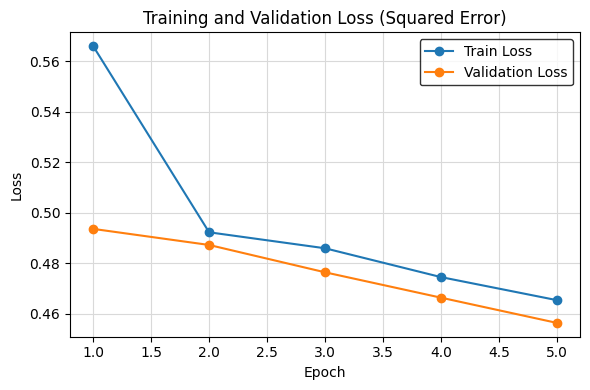

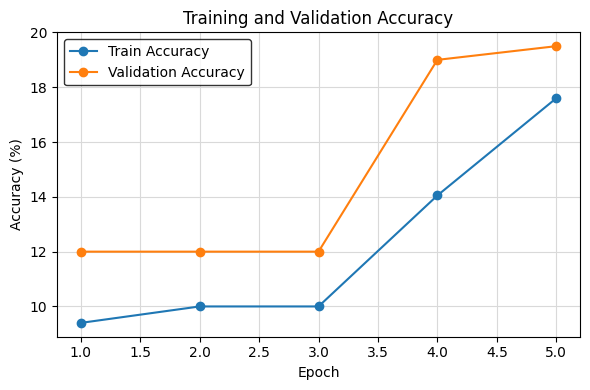

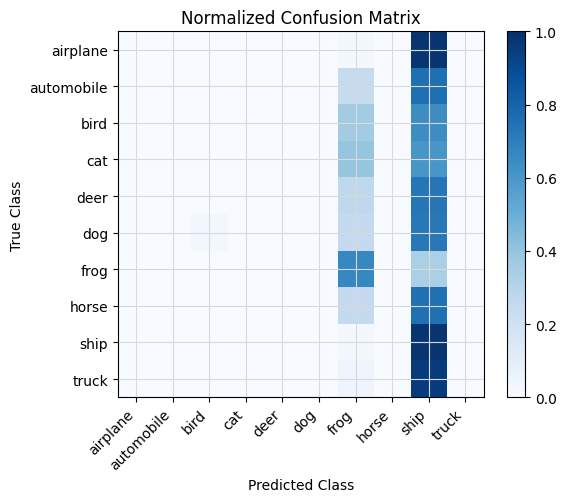

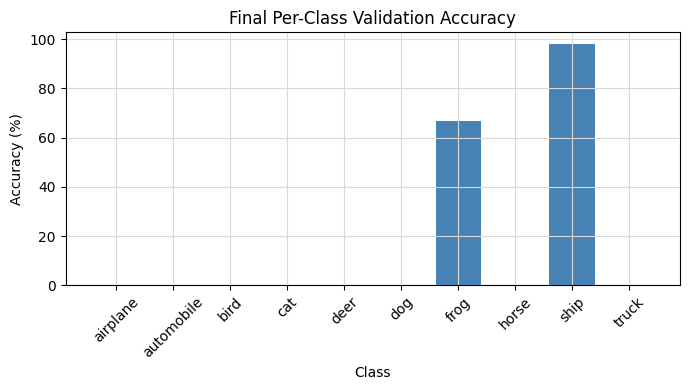

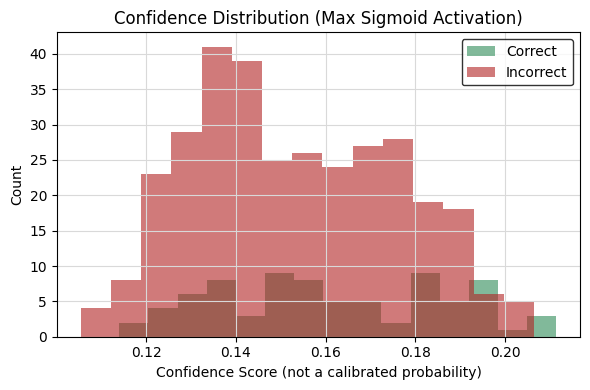

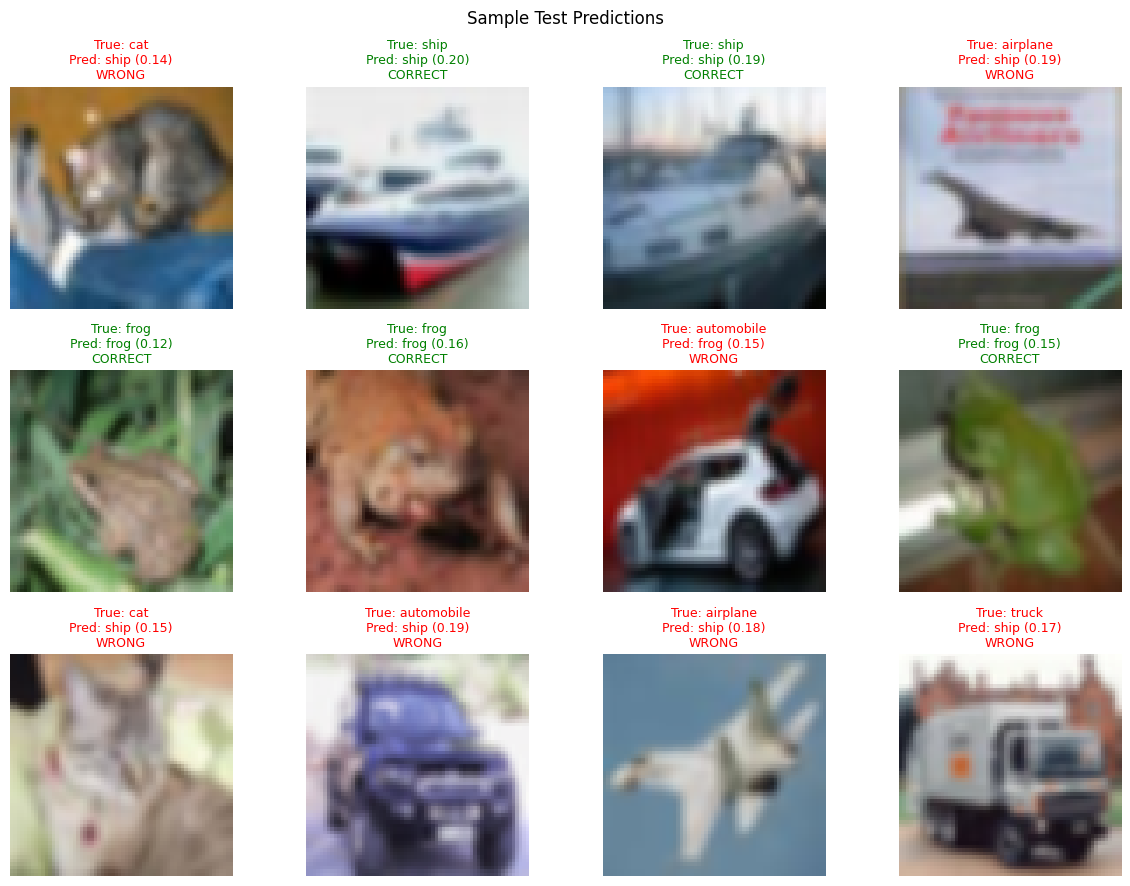

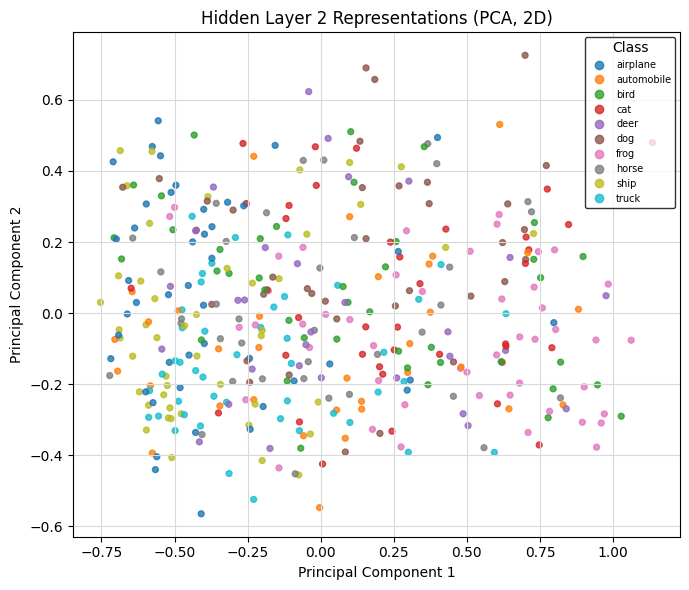

In [13]:
# ------------------------------------------------------------
# 11. STANDALONE EDUCATIONAL VISUALIZATIONS
# ------------------------------------------------------------

def style_axis(ax):
    ax.set_facecolor("white")
    ax.title.set_color("black")
    ax.xaxis.label.set_color("black")
    ax.yaxis.label.set_color("black")
    ax.tick_params(colors="black")
    for spine in ax.spines.values():
        spine.set_color("black")
    ax.grid(True, color="0.85")


epochs_range = list(range(1, NUM_EPOCHS + 1))

# --- Figure 1: Loss curves ---
fig1, ax1 = plt.subplots(figsize=(6, 4))
ax1.plot(epochs_range, history["train_loss"], marker="o", label="Train Loss")
ax1.plot(epochs_range, history["val_loss"], marker="o", label="Validation Loss")
ax1.set_title("Training and Validation Loss (Squared Error)")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()
style_axis(ax1)
plt.tight_layout()

# --- Figure 2: Accuracy curves ---
fig2, ax2 = plt.subplots(figsize=(6, 4))
ax2.plot(epochs_range, [a * 100 for a in history["train_acc"]], marker="o", label="Train Accuracy")
ax2.plot(epochs_range, [a * 100 for a in history["val_acc"]], marker="o", label="Validation Accuracy")
ax2.set_title("Training and Validation Accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy (%)")
ax2.legend()
style_axis(ax2)
plt.tight_layout()

# --- Figure 3: Normalized confusion matrix ---
conf_matrix = np.zeros((NUM_CLASSES, NUM_CLASSES))
for true_label, pred_label in zip(last_eval_labels, last_eval_predictions):
    conf_matrix[true_label, pred_label] += 1
row_sums = conf_matrix.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1
conf_matrix_norm = conf_matrix / row_sums

fig3, ax3 = plt.subplots(figsize=(6, 5))
im = ax3.imshow(conf_matrix_norm, cmap="Blues", vmin=0, vmax=1)
ax3.set_xticks(range(NUM_CLASSES))
ax3.set_yticks(range(NUM_CLASSES))
ax3.set_xticklabels(class_names, rotation=45, ha="right")
ax3.set_yticklabels(class_names)
ax3.set_title("Normalized Confusion Matrix")
ax3.set_xlabel("Predicted Class")
ax3.set_ylabel("True Class")
cbar = fig3.colorbar(im, ax=ax3)
cbar.ax.yaxis.set_tick_params(color="black")
plt.setp(cbar.ax.get_yticklabels(), color="black")
style_axis(ax3)
plt.tight_layout()

# --- Figure 4: Per-class validation accuracy bar chart ---
final_per_class_acc = history["val_per_class_acc"][-1] * 100
fig4, ax4 = plt.subplots(figsize=(7, 4))
ax4.bar(class_names, final_per_class_acc, color="steelblue")
ax4.set_title("Final Per-Class Validation Accuracy")
ax4.set_xlabel("Class")
ax4.set_ylabel("Accuracy (%)")
ax4.tick_params(axis="x", rotation=45)
style_axis(ax4)
plt.tight_layout()

# --- Figure 5: Confidence distributions ---
correct_confidences = last_eval_confidences[last_eval_correct_mask.astype(bool)]
incorrect_confidences = last_eval_confidences[~last_eval_correct_mask.astype(bool)]

fig5, ax5 = plt.subplots(figsize=(6, 4))
if len(correct_confidences) > 0:
    ax5.hist(correct_confidences, bins=15, alpha=0.6, label="Correct", color="seagreen")
if len(incorrect_confidences) > 0:
    ax5.hist(incorrect_confidences, bins=15, alpha=0.6, label="Incorrect", color="firebrick")
ax5.set_title("Confidence Distribution (Max Sigmoid Activation)")
ax5.set_xlabel("Confidence Score (not a calibrated probability)")
ax5.set_ylabel("Count")
ax5.legend()
style_axis(ax5)
plt.tight_layout()

# --- Figure 6: Sample predictions grid ---
def unnormalize(img_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img = img_tensor.cpu() * std + mean
    return torch.clamp(img, 0, 1).permute(1, 2, 0).numpy()


num_display = 12
fig6, axes6 = plt.subplots(3, 4, figsize=(12, 9))
axes6 = axes6.flatten()
for i in range(num_display):
    img_np = unnormalize(sample_test_images[i])
    true_label = sample_test_labels[i].item()
    pred_label = sample_pred_labels[i]
    conf = sample_confidences[i]
    is_correct = (true_label == pred_label)

    axes6[i].imshow(img_np)
    axes6[i].axis("off")
    mark = "CORRECT" if is_correct else "WRONG"
    title_color = "green" if is_correct else "red"
    axes6[i].set_title(
        f"True: {class_names[true_label]}\nPred: {class_names[pred_label]} ({conf:.2f})\n{mark}",
        color=title_color, fontsize=9
    )
fig6.suptitle("Sample Test Predictions", color="black")
plt.tight_layout()

# --- Figure 7: Hidden-layer-2 representation via PCA ---
# This directly reflects the paper's central idea: hidden units learn
# distributed internal representations of the task, not explicitly
# specified by the input/output encoding.
pca = PCA(n_components=2, random_state=SEED)
hidden2_2d = pca.fit_transform(last_hidden2_features)

fig7, ax7 = plt.subplots(figsize=(7, 6))
scatter = ax7.scatter(
    hidden2_2d[:, 0], hidden2_2d[:, 1],
    c=last_eval_labels, cmap="tab10", s=18, alpha=0.8
)
ax7.set_title("Hidden Layer 2 Representations (PCA, 2D)")
ax7.set_xlabel("Principal Component 1")
ax7.set_ylabel("Principal Component 2")
legend_handles, _ = scatter.legend_elements()
ax7.legend(legend_handles, class_names, title="Class", loc="best", fontsize=7)
style_axis(ax7)
plt.tight_layout()

Text(0.02, 0.98, 'H — Summary Scorecard\n-----------------------------\nBest Val Accuracy: 19.50% (Epoch 5)\nFinal Train Loss: 0.4653\nFinal Val Loss: 0.4563\nFinal Mean Per-Class Loss: 0.9233\nTrainable Parameters: 213,962\nTop Classes: ship (97.9%), frog (66.7%), bird (0.0%)\nLowest Classes: automobile (0.0%), horse (0.0%), truck (0.0%)\nMean Confidence (Correct): 0.162\nMean Confidence (Incorrect): 0.153\nDevice: cuda\nArchitecture: 768-256-64-10 (Sigmoid)\nLearning Rate: 0.1\nMomentum: 0.9')

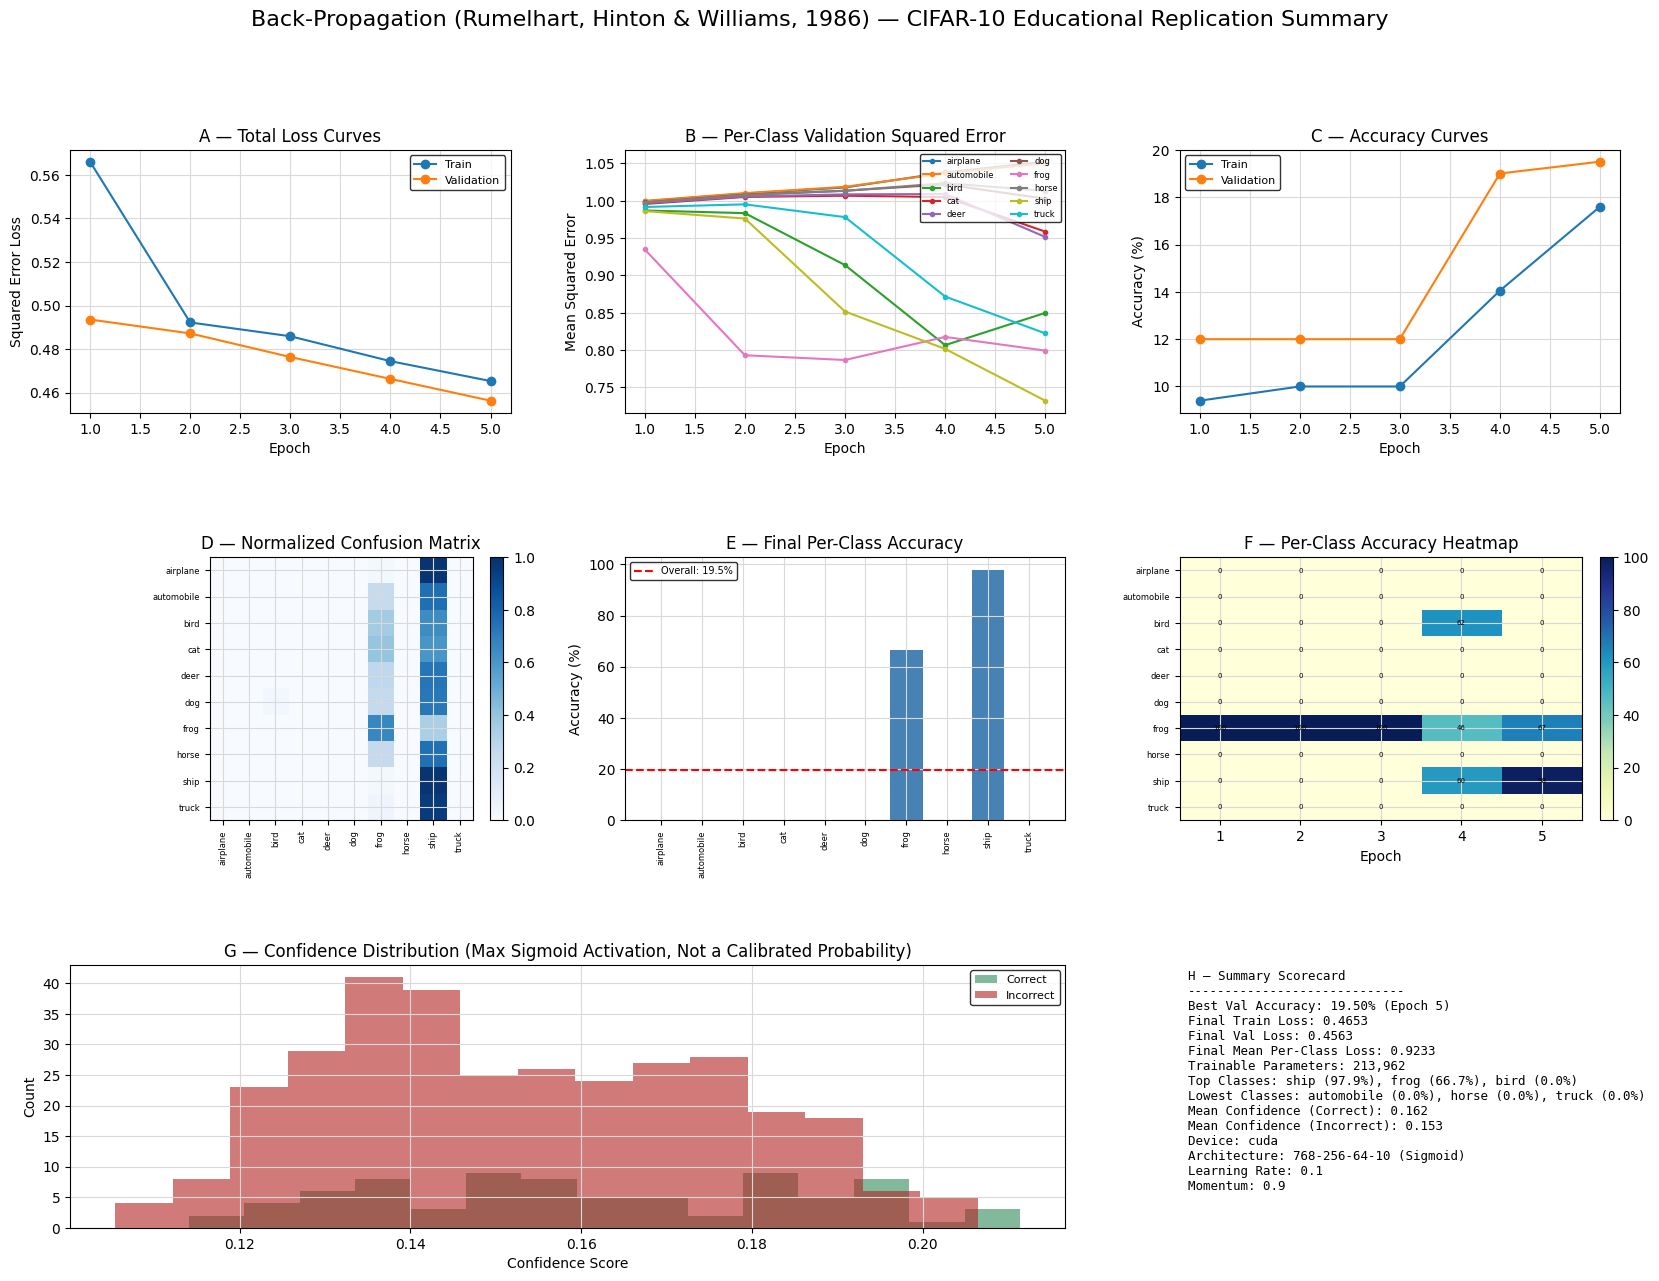

In [14]:
# ------------------------------------------------------------
# 12. FINAL MULTI-PANEL SUMMARY DASHBOARD
# ------------------------------------------------------------
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
})

fig = plt.figure(figsize=(20, 14))
fig.patch.set_facecolor("white")
gs = gridspec.GridSpec(3, 6, figure=fig, hspace=0.55, wspace=0.7)

fig.suptitle(
    "Back-Propagation (Rumelhart, Hinton & Williams, 1986) — "
    "CIFAR-10 Educational Replication Summary",
    fontsize=16, color="black", y=0.98
)

# Panel A — Total loss curves
axA = fig.add_subplot(gs[0, 0:2])
axA.plot(epochs_range, history["train_loss"], marker="o", label="Train")
axA.plot(epochs_range, history["val_loss"], marker="o", label="Validation")
axA.set_title("A — Total Loss Curves")
axA.set_xlabel("Epoch")
axA.set_ylabel("Squared Error Loss")
axA.legend(fontsize=8)
style_axis(axA)

# Panel B — Per-class squared-error curves (decomposition of the same objective)
axB = fig.add_subplot(gs[0, 2:4])
per_class_loss_matrix = np.array(history["val_per_class_loss"])  # (epochs, 10)
for c in range(NUM_CLASSES):
    axB.plot(epochs_range, per_class_loss_matrix[:, c], marker=".", label=class_names[c])
axB.set_title("B — Per-Class Validation Squared Error")
axB.set_xlabel("Epoch")
axB.set_ylabel("Mean Squared Error")
# These curves decompose the paper's single total squared-error
# objective (Eq. 3) by target class; they are not additional losses.
axB.legend(fontsize=6, ncol=2, loc="upper right")
style_axis(axB)

# Panel C — Accuracy curves
axC = fig.add_subplot(gs[0, 4:6])
axC.plot(epochs_range, [a * 100 for a in history["train_acc"]], marker="o", label="Train")
axC.plot(epochs_range, [a * 100 for a in history["val_acc"]], marker="o", label="Validation")
axC.set_title("C — Accuracy Curves")
axC.set_xlabel("Epoch")
axC.set_ylabel("Accuracy (%)")
axC.legend(fontsize=8)
style_axis(axC)

# Panel D — Normalized confusion matrix
axD = fig.add_subplot(gs[1, 0:2])
imD = axD.imshow(conf_matrix_norm, cmap="Blues", vmin=0, vmax=1)
axD.set_xticks(range(NUM_CLASSES))
axD.set_yticks(range(NUM_CLASSES))
axD.set_xticklabels(class_names, rotation=90, fontsize=6)
axD.set_yticklabels(class_names, fontsize=6)
axD.set_title("D — Normalized Confusion Matrix")
cbarD = fig.colorbar(imD, ax=axD, fraction=0.046, pad=0.04)
cbarD.ax.yaxis.set_tick_params(color="black")
plt.setp(cbarD.ax.get_yticklabels(), color="black")
style_axis(axD)

# Panel E — Final per-class accuracy
axE = fig.add_subplot(gs[1, 2:4])
axE.bar(class_names, final_per_class_acc, color="steelblue")
overall_val_acc = history["val_acc"][-1] * 100
axE.axhline(overall_val_acc, color="red", linestyle="--",
            label=f"Overall: {overall_val_acc:.1f}%")
axE.set_title("E — Final Per-Class Accuracy")
axE.set_ylabel("Accuracy (%)")
axE.tick_params(axis="x", rotation=90, labelsize=6)
axE.legend(fontsize=7)
style_axis(axE)

# Panel F — Epoch-wise per-class accuracy heatmap
axF = fig.add_subplot(gs[1, 4:6])
per_class_acc_matrix = np.array(history["val_per_class_acc"]) * 100  # (epochs, 10)
imF = axF.imshow(per_class_acc_matrix.T, cmap="YlGnBu", aspect="auto", vmin=0, vmax=100)
axF.set_yticks(range(NUM_CLASSES))
axF.set_yticklabels(class_names, fontsize=6)
axF.set_xticks(range(NUM_EPOCHS))
axF.set_xticklabels([str(e) for e in epochs_range])
axF.set_xlabel("Epoch")
axF.set_title("F — Per-Class Accuracy Heatmap")
for i in range(NUM_CLASSES):
    for j in range(NUM_EPOCHS):
        val = per_class_acc_matrix[j, i]
        axF.text(j, i, f"{val:.0f}", ha="center", va="center",
                  color="black", fontsize=5)
cbarF = fig.colorbar(imF, ax=axF, fraction=0.046, pad=0.04)
cbarF.ax.yaxis.set_tick_params(color="black")
plt.setp(cbarF.ax.get_yticklabels(), color="black")
style_axis(axF)

# Panel G — Confidence distribution
axG = fig.add_subplot(gs[2, 0:4])
if len(correct_confidences) > 0:
    axG.hist(correct_confidences, bins=15, alpha=0.6, label="Correct", color="seagreen")
if len(incorrect_confidences) > 0:
    axG.hist(incorrect_confidences, bins=15, alpha=0.6, label="Incorrect", color="firebrick")
axG.set_title("G — Confidence Distribution (Max Sigmoid Activation, Not a Calibrated Probability)")
axG.set_xlabel("Confidence Score")
axG.set_ylabel("Count")
axG.legend(fontsize=8)
style_axis(axG)

# Panel H — Text-based summary scorecard
axH = fig.add_subplot(gs[2, 4:6])
axH.axis("off")

best_epoch_idx = int(np.argmax(history["val_acc"]))
best_val_acc = history["val_acc"][best_epoch_idx] * 100
best_epoch_num = best_epoch_idx + 1

final_train_loss = history["train_loss"][-1]
final_val_loss = history["val_loss"][-1]
final_mean_per_class_loss = float(np.mean(history["val_per_class_loss"][-1]))

total_params = (
    W1.numel() + b1.numel() +
    W2.numel() + b2.numel() +
    W3.numel() + b3.numel()
)

ranked_idx = np.argsort(-final_per_class_acc)
top3_classes = [f"{class_names[i]} ({final_per_class_acc[i]:.1f}%)" for i in ranked_idx[:3]]
bottom3_classes = [f"{class_names[i]} ({final_per_class_acc[i]:.1f}%)" for i in ranked_idx[-3:]]

mean_conf_correct = f"{correct_confidences.mean():.3f}" if len(correct_confidences) > 0 else "N/A"
mean_conf_incorrect = f"{incorrect_confidences.mean():.3f}" if len(incorrect_confidences) > 0 else "N/A"

summary_text = (
    "H — Summary Scorecard\n"
    "-----------------------------\n"
    f"Best Val Accuracy: {best_val_acc:.2f}% (Epoch {best_epoch_num})\n"
    f"Final Train Loss: {final_train_loss:.4f}\n"
    f"Final Val Loss: {final_val_loss:.4f}\n"
    f"Final Mean Per-Class Loss: {final_mean_per_class_loss:.4f}\n"
    f"Trainable Parameters: {total_params:,}\n"
    f"Top Classes: {', '.join(top3_classes)}\n"
    f"Lowest Classes: {', '.join(bottom3_classes)}\n"
    f"Mean Confidence (Correct): {mean_conf_correct}\n"
    f"Mean Confidence (Incorrect): {mean_conf_incorrect}\n"
    f"Device: {device}\n"
    f"Architecture: 768-256-64-10 (Sigmoid)\n"
    f"Learning Rate: {LEARNING_RATE}\n"
    f"Momentum: {MOMENTUM}"
)

axH.text(
    0.02, 0.98, summary_text,
    transform=axH.transAxes, fontsize=9, color="black",
    verticalalignment="top", family="monospace"
)

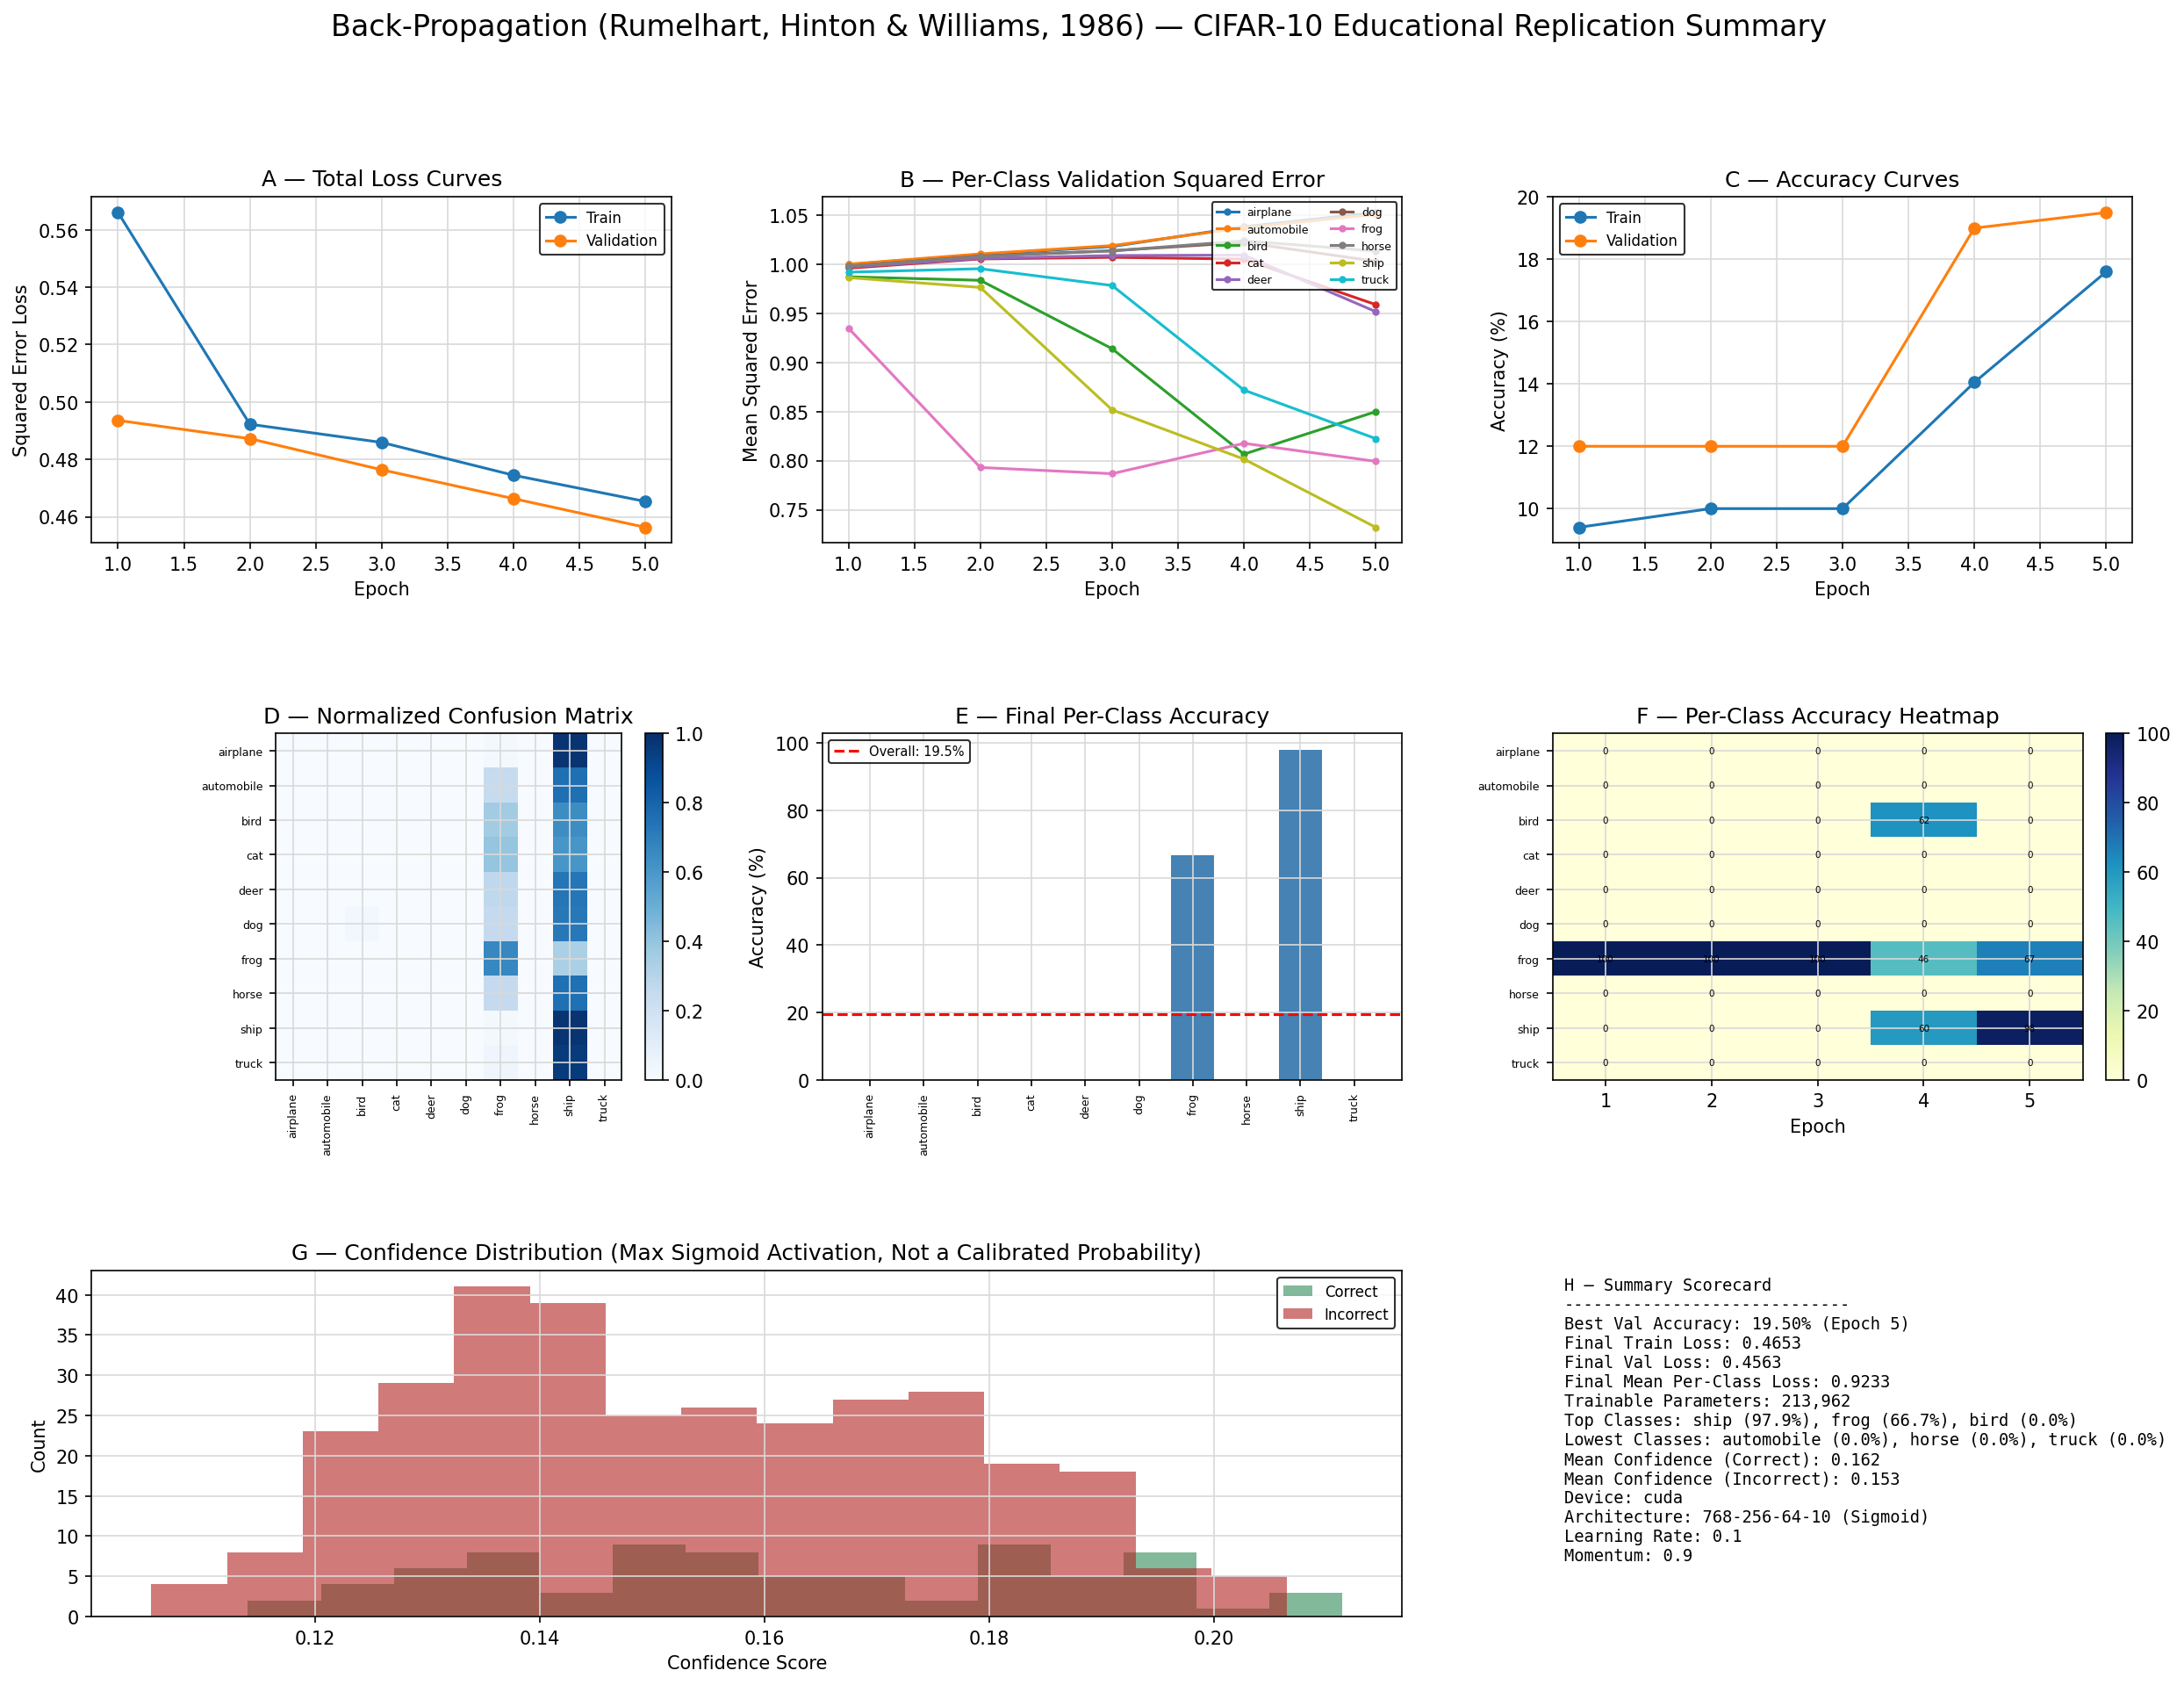

In [15]:
# ------------------------------------------------------------
# 13. DISPLAY DASHBOARD (in-memory, no disk save, no plt.show)
# ------------------------------------------------------------
buf = BytesIO()
fig.savefig(
    buf,
    format="png",
    dpi=150,
    bbox_inches="tight",
    facecolor="white"
)
buf.seek(0)
display(IPImage(data=buf.read()))
buf.close()
plt.close(fig)

### Overview
Panels A–C track the evolution of the paper's squared-error objective and classification accuracy across five training epochs on a subsampled CIFAR-10 task (2,000 train / 400 test images), using the manually implemented back-propagation procedure with sigmoid units and momentum-based gradient descent.

### Key Findings
- Training and validation squared-error loss both decrease monotonically (Panel A), from roughly 0.57/0.49 to 0.47/0.46, indicating the manual gradient computation is functioning correctly and the network is fitting the data.
- Validation loss remains consistently lower than training loss throughout, and validation accuracy (Panel C) overtakes training accuracy after epoch 3, rising sharply to ~19–20% while training accuracy reaches only ~17.6%.
- Per-class squared error (Panel B) is essentially flat near 1.0 for eight of ten classes, while only "frog" and, later, "ship" show meaningful error reduction.

### Discussion
The steady decline in total loss confirms that the hand-derived chain-rule gradients (Eqs. 4–7) and momentum update (Eq. 9) are correctly minimizing the objective, validating the faithfulness of the manual implementation to the paper's procedure. However, the accuracy gap—validation exceeding training—combined with near-stagnant per-class loss for most categories, indicates the network is not learning ten-way discrimination but instead converging toward a narrow subset of output classes that happen to minimize aggregate squared error. This is consistent with known limitations of sigmoid-output, squared-error objectives for multi-class problems: the loss surface offers little gradient signal to separate classes once outputs saturate near 0 or 1, and with only 2,000 training samples and heavy spatial compression (64×64 → 16×16 pooling), the effective input signal is too weak to support fine-grained feature learning within five epochs.

### Limitations
Accuracy figures at this scale (~20%, only marginally above the 10% chance baseline) are not statistically robust given the small evaluation set (400 samples) and short training schedule. The mismatch between train and validation accuracy trends is atypical and likely reflects noise and class imbalance in per-batch collapse dynamics rather than genuine generalization. These curves alone cannot establish whether the architecture is representationally sound; they must be read alongside the confusion matrix and per-class panels below.

---

### Overview
Panels D–F characterize the model's per-class prediction behavior at the end of training: a normalized confusion matrix, final per-class accuracy bar chart, and an epoch-wise per-class accuracy heatmap.

### Key Findings
- The confusion matrix (Panel D) shows prediction mass concentrated almost entirely in the "frog" and "ship" columns, regardless of the true class; most other columns are empty.
- Final per-class accuracy (Panel E) confirms this: only "frog" (~67%) and "ship" (~98%) achieve nonzero accuracy, while the remaining eight classes sit at 0%.
- The heatmap (Panel F) reveals a temporal pattern: "frog" dominates predictions in early epochs (100% at epochs 1–3), after which "ship" abruptly takes over by epochs 4–5, with a brief transient bump for "bird" around epoch 4.

### Discussion
This pattern is a clear instance of **output collapse**, a well-documented failure mode when squared-error loss is paired with sigmoid output units in multi-class settings: because each output unit is optimized independently toward a fixed 0/1 target rather than through a competitive softmax normalization, the network can reduce aggregate error simply by learning to consistently activate one or two "safe" output units rather than learning ten separate discriminative boundaries. The shift from a "frog-dominant" to a "ship-dominant" regime between epochs 3 and 4 suggests the network is oscillating between local optima in a poorly conditioned loss landscape, plausibly linked to sigmoid saturation, the fairly aggressive learning rate (0.1) combined with momentum (0.9), and the limited representational capacity remaining after average-pooling to 16×16. While this behavior faithfully reproduces the paper's specified architecture and update rule, it also illustrates precisely the sensitivity to local minima and weight-space geometry that Rumelhart, Hinton, and Williams (1986) acknowledge as a known risk of gradient descent, here manifesting as class collapse rather than a stalled global loss.

### Discussion (continued interpretation)
The transient "bird" activation at epoch 4 (Panel F) suggests brief escape from the dominant local solution before re-collapsing to "ship," consistent with the paper's own observation that additional weight-space dimensions can provide temporary paths around poor local minima, though here the network does not stabilize on a broadly discriminative solution within the allotted five epochs.

### Limitations
The result is strongly confounded by the small dataset size, short training duration, and simplified pooled input, none of which are representative of the original paper's carefully hand-tuned single-task demonstrations (e.g., symmetry detection, family trees). The collapse to two classes is an implementation-scale artifact of the sigmoid + squared-error formulation rather than evidence against the correctness of the back-propagation derivation itself; a longer training run, per-class error weighting, or a cross-entropy objective would likely be needed to disambiguate genuine learning capacity from optimization pathology.

---

### Overview
Panel G presents the distribution of prediction confidence (maximum sigmoid output activation) separately for correct and incorrect predictions, intended to assess whether the network's activation strength is informative of prediction reliability.

### Key Findings
- Both correct and incorrect predictions cluster in a narrow, low confidence range (~0.10–0.21).
- The mean confidence for correct predictions (0.162) is only marginally higher than for incorrect predictions (0.153), and the two histograms overlap almost completely.

### Discussion
The near-total overlap between correct and incorrect confidence distributions indicates the network's output activations carry little discriminative information about prediction reliability, consistent with the collapsed, two-class prediction regime identified in Panels D–F. Because sigmoid outputs are optimized independently rather than through a normalized (softmax) competition, their magnitudes do not behave as calibrated probabilities, and low absolute activation values across the board reflect general underfitting rather than principled uncertainty estimation. This finding is consistent with the code's own annotation that the confidence score is an activation magnitude, not a calibrated probability, and empirically demonstrates why that caveat is necessary.

### Limitations
Confidence calibration cannot be meaningfully assessed on a model that has not learned to discriminate most classes; the metric here primarily reflects the collapse behavior rather than a genuine test of calibration quality. A properly trained model (more epochs, larger dataset, or a normalized output layer) would be required to draw substantive conclusions about confidence-accuracy alignment.

---

### Overview
Panel H aggregates the experiment into a text-based scorecard, summarizing best accuracy, loss values, parameter count, and top/bottom-performing classes, providing a consolidated view of overall model performance and configuration.

### Key Findings
- Best validation accuracy: 19.50% at epoch 5, against a 10% chance baseline.
- Final training and validation losses (0.4653 and 0.4563, respectively) are close in magnitude, consistent with the smooth convergence seen in Panel A.
- Top-performing classes are "ship" (97.9%) and "frog" (66.7%); all other eight classes report 0% accuracy.
- Total trainable parameters: 213,962, consistent with the specified 768–256–64–10 fully-connected sigmoid architecture.

### Discussion
The scorecard corroborates the pattern established across Panels D–G: the model achieves above-chance aggregate accuracy almost entirely by exploiting two classes, rather than through balanced multi-class learning. This is a meaningful and expected outcome for an educational replication that deliberately omits modern stabilizing techniques (softmax, cross-entropy, batch normalization, convolutional feature extraction) in favor of fidelity to the 1986 paper's original formulation. The results support the historical claims of the original paper only in a narrow sense—that gradient descent via back-propagation successfully reduces a defined error function and can construct internal (if here degenerate) representations—but they do not replicate the qualitative success reported in the original symmetry-detection or family-tree experiments, which involved much smaller, cleanly structured, low-dimensional problems well-suited to the sigmoid/squared-error formulation.

### Limitations
The scorecard, by design, reports point-in-time final-epoch statistics and cannot capture the model's transient dynamics (e.g., the epoch-4 "bird" spike) or variance across random seeds. The comparison between this modern high-dimensional image task and the original paper's small symbolic tasks is inherently limited: the collapse observed here is best interpreted as a demonstration of the boundary conditions under which the 1986 formulation remains effective, rather than a failure of the underlying back-propagation algorithm itself.

# Related Work Reference Table
**Paper:** Learning Representations by Back-Propagating Errors (Rumelhart, Hinton & Williams, 1986)

| Author(s) | Year | Title | Venue | Connection to This Paper |
|---|---|---|---|---|
| Rosenblatt, F. | 1961 | *Principles of Neurodynamics* | Spartan, Washington, DC (Book) | Establishes the perceptron-convergence procedure, the earlier and more limited learning rule that the authors explicitly contrast with back-propagation; motivates the need for a more powerful procedure capable of handling hidden units. |
| Minsky, M. L. & Papert, S. | 1969 | *Perceptrons* | MIT Press, Cambridge (Book) | Provides the formal analysis of perceptron limitations, including the argument (cited for a "more formal proof") that intermediate (hidden) units are required for certain tasks such as symmetry detection; frames the representational gap the paper addresses. |
| Le Cun, Y. | 1985 | (Untitled conference contribution) | *Proc. Cognitiva 85*, pp. 599–604 | Cited as an independent co-discoverer of a variant of the back-propagation learning procedure, situating the paper's contribution within concurrent, parallel developments of the same general idea. |
| Rumelhart, D. E., Hinton, G. E. & Williams, R. J. | 1986 | "Learning Internal Representations by Error Propagation," in *Parallel Distributed Processing: Explorations in the Microstructure of Cognition, Vol. 1: Foundations* (eds Rumelhart, D. E. & McClelland, J. L.) | MIT Press, Cambridge, pp. 318–362 | The authors' own extended companion treatment of the same learning procedure, including its application to iterative/recurrent networks; referenced for the fuller derivation of the equivalence between layered and iterative nets discussed in this Nature letter. |
| Parker, D. | — | Personal communication (unpublished) | N/A | Noted as an independent discoverer of a variant of the back-propagation procedure, alongside Le Cun, underscoring that the method emerged from multiple concurrent lines of research rather than being wholly novel to this paper. |

**Note:** The reference list of this Nature letter is brief (four numbered citations plus one personal communication), consistent with the short-format "Letters to Nature" style. No other formal related-work citations appear in the text.